### Import Libraries

In [19]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


### Paths

In [20]:
TRAIN_DIR = Path("../processed/train")
VALID_DIR = Path("../processed/valid")
TEST_DIR = Path("../processed/test")

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

### Configuration

In [21]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 30

SEED = 42

### Load Dataset

#### Training

In [22]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 3742 files belonging to 6 classes.


#### Validation

In [23]:
valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 801 files belonging to 6 classes.


#### Test

In [24]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 805 files belonging to 6 classes.


### Class Names

In [25]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['bacterial_leaf_blight', 'blast', 'brown_spot', 'healthy', 'leaf_scald', 'sheath_blight']
Number of classes: 6


### Data Augmentation

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
])

### Prefetch Dataset

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### Compute Class Weights

#### Extract Labels

In [28]:
labels = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

#### Compute Weights

In [29]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    i: weights[i]
    for i in range(len(weights))
}

class_weights

{0: np.float64(1.029152915291529),
 1: np.float64(0.901252408477842),
 2: np.float64(0.9253214638971315),
 3: np.float64(1.0999412110523221),
 4: np.float64(1.0922358435493287),
 5: np.float64(0.9868143459915611)}

### Build MobileNetV2

In [30]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

### Build Final Model

In [31]:
inputs = tf.keras.Input(
    shape=(224,224,3)
)

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = models.Model(inputs, outputs)

### Compile Model

In [32]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Model Summary

In [33]:
model.summary()

Model: "functional_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Callbacks

In [34]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

### Train Model

In [35]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 131s 952ms/step - accuracy: 0.4361 - loss: 1.4562 - val_accuracy: 0.6017 - val_loss: 1.0330 - learning_rate: 0.0010
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 135s 894ms/step - accuracy: 0.6024 - loss: 1.0408 - val_accuracy: 0.6717 - val_loss: 0.8778 - learning_rate: 0.0010
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 106s 902ms/step - accuracy: 0.6403 - loss: 0.9350 - val_accuracy: 0.6879 - val_loss: 0.8198 - learning_rate: 0.0010
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 104s 888ms/step - accuracy: 0.6780 - loss: 0.8472 - val_accuracy: 0.7141 - val_loss: 0.7935 - learning_rate: 0.0010
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 106s 908ms/step - accuracy: 0.6967 - loss: 0.8017 - val_accuracy: 0.7316 - val_loss: 0.7346 - learning_rate: 0.0010
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 103s 881ms/step - accuracy: 0.6991 - loss: 0.7857 - val_accuracy: 0.7503 - val_loss: 0.7056 - learning_rate: 0.0010
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 104s 885ms/step - accura

In [36]:
import numpy as np

preds = model.predict(test_ds, verbose=0)

predicted = np.argmax(preds, axis=1)

true = np.concatenate([y.numpy() for x, y in test_ds])

print("Accuracy:",
      np.mean(predicted == true))

print(np.bincount(predicted))

Accuracy: 0.7975155279503106
[121 151 139 130 109 155]


### Save Final Model

In [37]:
model.save(
    "../models/agrolens_mobilenetv3.keras"
)

### Plot Accuracy

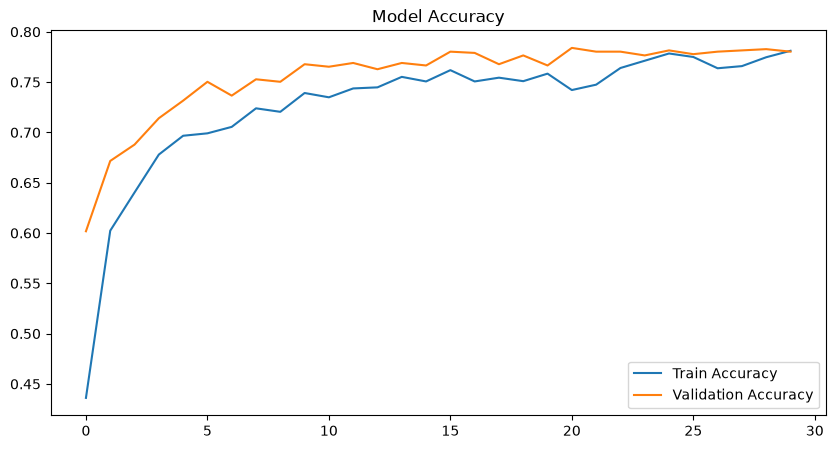

In [38]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.legend()

plt.title("Model Accuracy")

plt.show()

### Plot Loss

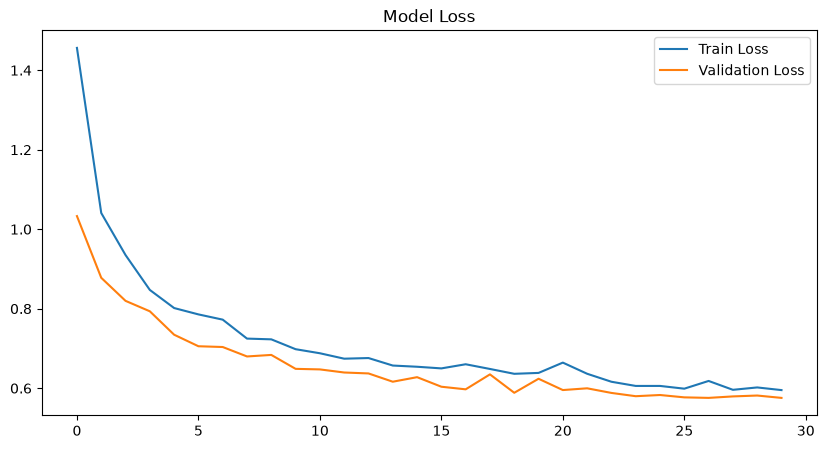

In [39]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title("Model Loss")

plt.show()

### Evaluate on Test Set

In [40]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 651ms/step - accuracy: 0.7975 - loss: 0.5720
Test Accuracy: 0.7975155115127563
Test Loss: 0.5719594359397888
